## §0 · Config & Environment Setup

In [14]:
import os, glob, gc, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130, "axes.grid": True, "grid.alpha": .3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "font.family": "DejaVu Sans"
})

# ── Resolve project root (works whether notebook CWD is project root or notebooks/) ──
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FIG_DIR = PROJECT_ROOT / "figures" / "eda"
OUT_DIR = PROJECT_ROOT / "outputs" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Sampling config (matches GRU.ipynb for consistency) ──
SAMPLE_USER_MOD  = 100       # ~1% users; set None for full dataset (needs large RAM)
CHUNK            = 2_000_000
SESSION_GAP_MIN  = 30        # minutes of inactivity = new session

# ── Behavior event mapping (cosmetics Kaggle → internal schema) ──
EVENT_RENAME = {
    "view":             "detail_click",
    "cart":             "add_to_cart",
    "remove_from_cart": "remove_cart",
    "purchase":         "purchase",
}
BEHAV_ORDER  = ["detail_click", "add_to_cart", "remove_cart", "purchase"]
BEHAV_LABEL  = {"detail_click": "View/Detail", "add_to_cart": "Add to Cart",
                 "remove_cart": "Remove Cart", "purchase": "Purchase"}

# ── Time-period definition (7 buckets from Colab v2.8) ──
PERIOD_MAP = {
    "morning_mid":    (6,  9,  "#7fb3d5"),
    "lunch_peak":     (9,  13, "#5499c7"),
    "afternoon_mid":  (13, 17, "#2e86c1"),
    "commute_low":    (17, 19, "#aeb6bf"),
    "evening_prime":  (19, 22, "#e59866"),
    "late_night_peak":(22, 24, "#dc7633"),
    "overnight_low":  (0,   6, "#9aa5b1"),
}
PERIOD_ORDER  = ["overnight_low", "morning_mid", "lunch_peak",
                 "afternoon_mid", "commute_low", "evening_prime", "late_night_peak"]
PERIOD_COLOR  = {k: v[2] for k, v in PERIOD_MAP.items()}
PERIOD_LABEL  = {
    "overnight_low":   "Đêm khuya 0-6h",
    "morning_mid":     "Sáng 6-9h",
    "lunch_peak":      "Trưa 9-13h",
    "afternoon_mid":   "Chiều 13-17h",
    "commute_low":     "Tan sở 17-19h",
    "evening_prime":   "Tối prime 19-22h",
    "late_night_peak": "Đêm muộn 22-24h",
}
def hour_to_period(h):
    if   0  <= h <  6: return "overnight_low"
    elif 6  <= h <  9: return "morning_mid"
    elif 9  <= h < 13: return "lunch_peak"
    elif 13 <= h < 17: return "afternoon_mid"
    elif 17 <= h < 19: return "commute_low"
    elif 19 <= h < 22: return "evening_prime"
    else:              return "late_night_peak"

print("§0 Config OK — Behavioral EDA for Cosmetics Dataset")
print(f"  FIG_DIR : {FIG_DIR}")
print(f"  OUT_DIR : {OUT_DIR}")


§0 Config OK — Behavioral EDA for Cosmetics Dataset
  FIG_DIR : /Volumes/PROJECTS/ecommerce-causal-analysis/figures/eda
  OUT_DIR : /Volumes/PROJECTS/ecommerce-causal-analysis/outputs/eda


## §1 · Data Loading & Feature Engineering

In [15]:
import kagglehub

_path = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-cosmetics-shop")
_files = sorted(glob.glob(os.path.join(_path, "**", "*.csv"), recursive=True))
_files = [f for f in _files if os.path.getsize(f) > 1_000_000]
print("CSV files found:", [os.path.basename(f) for f in _files])

COLS = ["event_time", "event_type", "product_id", "brand", "price", "user_id"]
DT   = {"event_type": "category", "product_id": "int64", "price": "float32",
        "user_id": "int64", "brand": "string"}

parts = []
for f in _files:
    for ch in pd.read_csv(f, usecols=COLS, dtype=DT, chunksize=CHUNK):
        ch = ch.dropna(subset=["event_time", "user_id", "price"])
        ch = ch[ch["price"] > 0]
        if SAMPLE_USER_MOD is not None:
            ch = ch[ch["user_id"] % SAMPLE_USER_MOD == 0]
        parts.append(ch)

df = pd.concat(parts, ignore_index=True); del parts; gc.collect()

# ── Parse timestamps ──
df["ts"] = pd.to_datetime(df["event_time"].astype(str).str[:19],
                          format="%Y-%m-%d %H:%M:%S", errors="coerce")
df = df.dropna(subset=["ts"]).copy()
df["user_id"]    = df["user_id"].astype(str)
df["product_id"] = df["product_id"].astype(str)
df["brand"]      = df["brand"].fillna("unknown").astype(str).str.lower()

# ── Map event types ──
df["event_type_behav"] = df["event_type"].astype(str).map(EVENT_RENAME)
df = df.dropna(subset=["event_type_behav"]).copy()

# ── Reference price & discount depth (non-leaking) ──
df = df.sort_values(["user_id", "ts"]).reset_index(drop=True)
prod_ref = df.groupby("product_id")["price"].quantile(0.90).rename("ref_price")
df = df.merge(prod_ref, on="product_id", how="left")
df["ref_price"]      = df[["ref_price", "price"]].max(axis=1)
df["discount_depth"] = (1.0 - df["price"] / df["ref_price"]).clip(0.0, 0.5)

# ── Temporal features ──
df["hour"]          = df["ts"].dt.hour
df["dayofweek"]     = df["ts"].dt.dayofweek   # 0=Mon, 6=Sun
df["dom"]           = df["ts"].dt.day
df["month"]         = df["ts"].dt.month
df["salary_period"] = df["dom"].map(lambda d: 1 if d in list(range(1,6)) + [15, 16, 25, 26] else 0)
df["time_period"]   = df["hour"].map(hour_to_period)

# ── Indicator columns ──
for bev in BEHAV_ORDER:
    df[f"is_{bev}"] = (df["event_type_behav"] == bev).astype(int)

# ── Session segmentation (30-min gap) ──
df["prev_ts"]    = df.groupby("user_id")["ts"].shift(1)
df["gap_min"]    = (df["ts"] - df["prev_ts"]).dt.total_seconds() / 60
df["new_sess"]   = (df["prev_ts"].isna() | (df["gap_min"] > SESSION_GAP_MIN)).astype(int)
df["sess_num"]   = df.groupby("user_id")["new_sess"].cumsum()
df["session_id"] = df["user_id"] + "_S" + df["sess_num"].astype(str)

# ── Top 10 brands (by total events) ──
top10_brands = df["brand"].value_counts().head(10).index.tolist()
df["brand_group"] = df["brand"].where(df["brand"].isin(top10_brands), other="others")

_pur = df[df["is_purchase"] == 1]
print(f"\n{'='*60}")
print(f"Tổng events (sampled)  : {len(df):,}")
print(f"Unique users           : {df['user_id'].nunique():,}")
print(f"Unique products        : {df['product_id'].nunique():,}")
print(f"Unique sessions        : {df['session_id'].nunique():,}")
print(f"Purchase events        : {len(_pur):,}  ({len(_pur)/len(df)*100:.2f}%)")
print(f"Date range             : {df['ts'].min().date()} → {df['ts'].max().date()}")
print(f"Top 10 brands          : {top10_brands}")
print('='*60)
df.head(3)


CSV files found: ['2019-Dec.csv', '2019-Nov.csv', '2019-Oct.csv', '2020-Feb.csv', '2020-Jan.csv']

Tổng events (sampled)  : 215,367
Unique users           : 16,419
Unique products        : 26,116
Unique sessions        : 33,955
Purchase events        : 14,194  (6.59%)
Date range             : 2019-10-01 → 2020-02-29
Top 10 brands          : ['unknown', 'runail', 'irisk', 'grattol', 'masura', 'ingarden', 'bpw.style', 'estel', 'kapous', 'pole']


,event_time,event_type,product_id,brand,price,user_id,ts,event_type_behav,ref_price,discount_depth,...,is_detail_click,is_add_to_cart,is_remove_cart,is_purchase,prev_ts,gap_min,new_sess,sess_num,session_id,brand_group
0,2019-11-28 10:12:24 UTC,view,5862022,unknown,5.56,107768800,2019-11-28 10:12:24,detail_click,5.56,0.0,...,1,0,0,0,NaT,NaN,1,1,107768800_S1,unknown
1,2019-12-13 15:44:56 UTC,view,5861731,unknown,11.67,107768800,2019-12-13 15:44:56,detail_click,11.67,0.0,...,1,0,0,0,2019-11-28 10:12:24,21932.533333,1,2,107768800_S2,unknown
2,2019-12-13 15:45:24 UTC,view,5912728,keune,29.32,107768800,2019-12-13 15:45:24,detail_click,29.32,0.0,...,1,0,0,0,2019-12-13 15:44:56,0.466667,0,2,107768800_S2,others


## §2 · Radar Chart: Behavioral Profile by Brand
Phân phối 4 hành vi quyết định (bỏ detail/view) theo top 10 brand — mỗi hàng cộng = 100%.

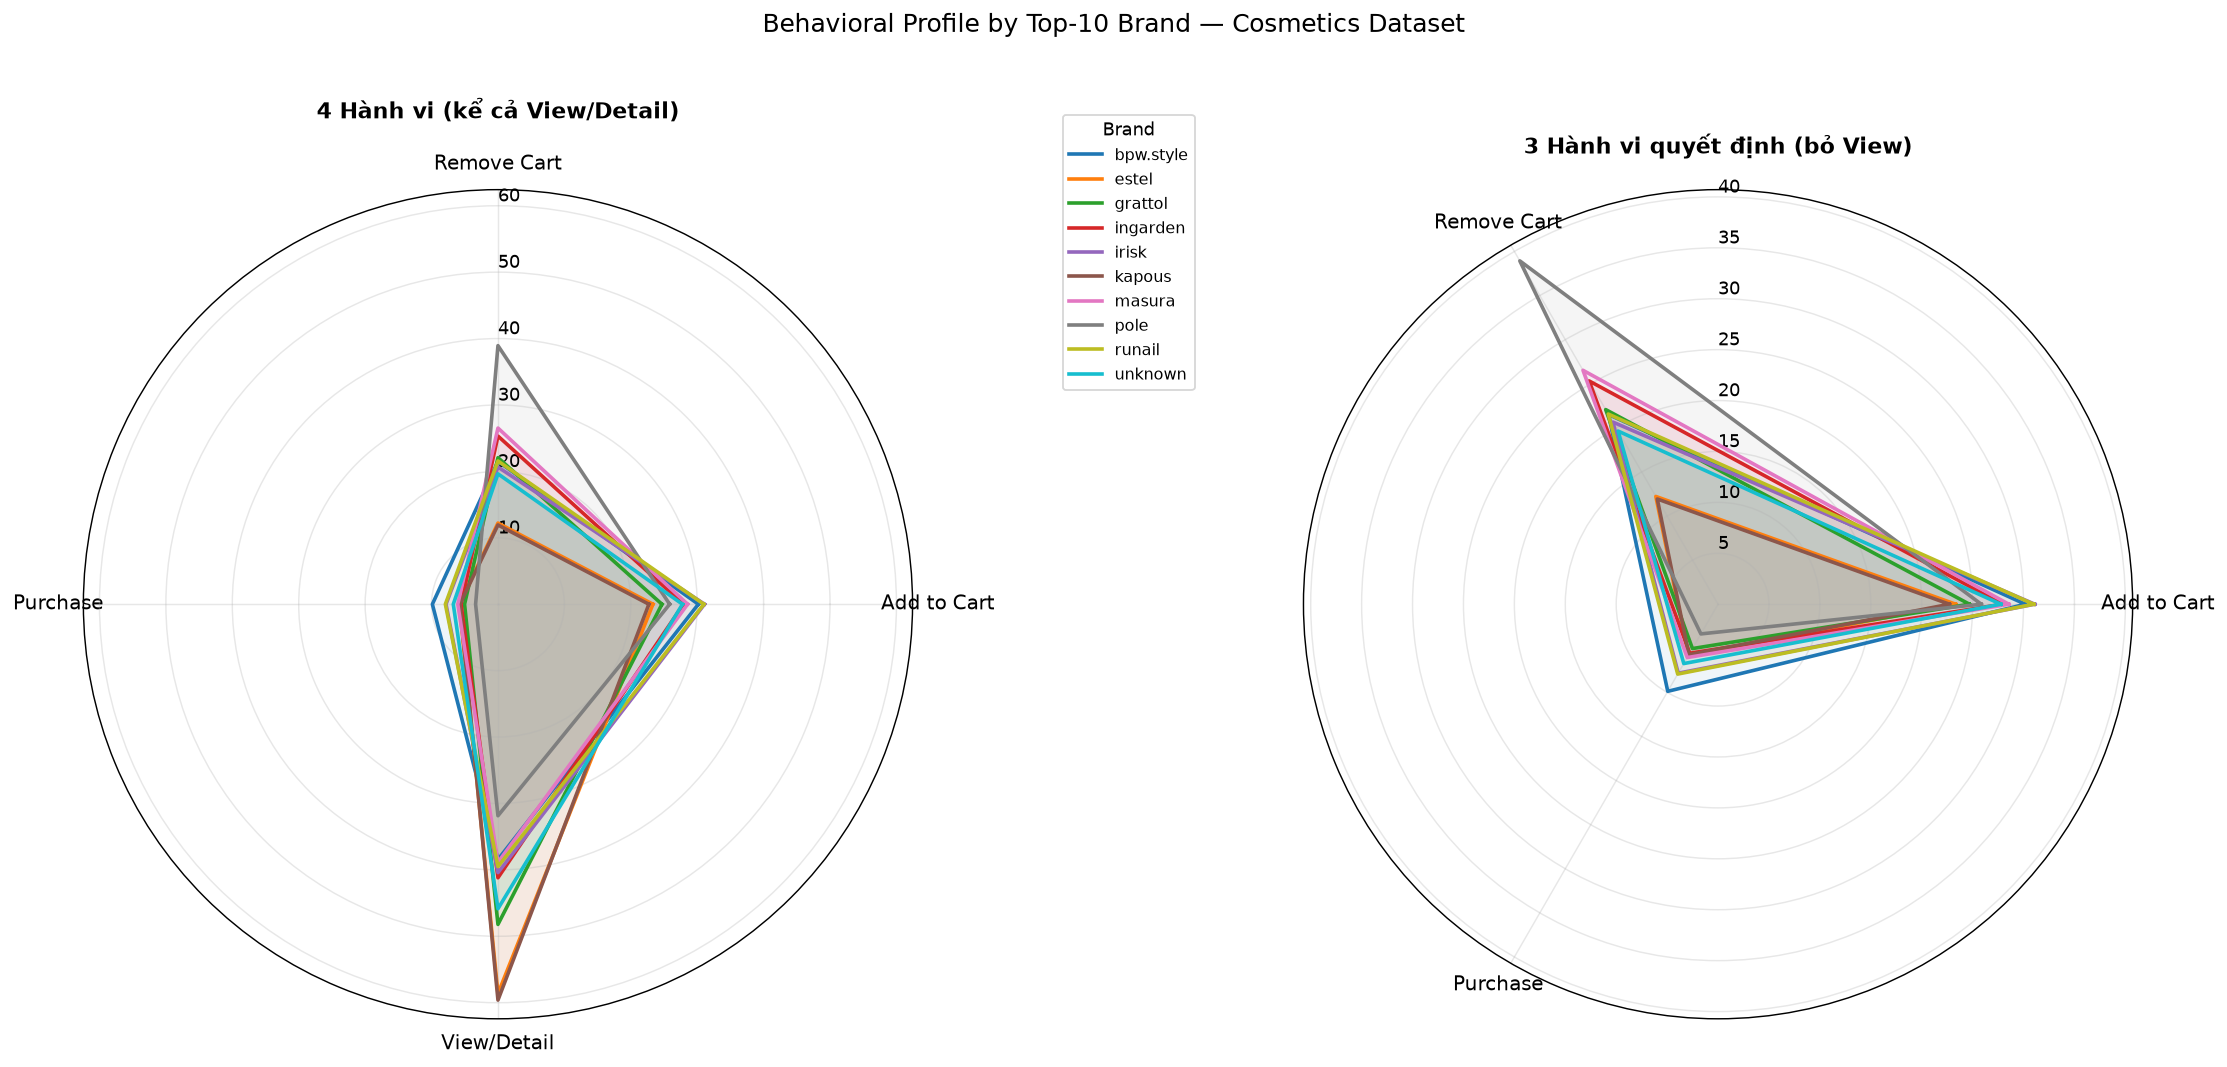

Tỷ lệ % hành vi theo brand (4 axes):
event_type_behav  add_to_cart  remove_cart  purchase  detail_click
brand_group                                                       
bpw.style                30.2         21.5       9.9          38.4
estel                    23.3         12.2       5.8          58.6
grattol                  24.7         22.1       5.0          48.2
ingarden                 27.9         25.3       5.6          41.2
irisk                    31.1         20.7       7.8          40.4
kapous                   22.7         11.9       5.7          59.6
masura                   28.6         26.5       6.0          38.9
pole                     25.9         38.9       3.4          31.8
runail                   31.0         21.6       7.9          39.5
unknown                  27.8         19.6       6.7          45.9


In [16]:
# ── Only non-view events → 4 axes sum to 100% per brand ──
DISC      = ["add_to_cart", "remove_cart", "purchase", "detail_click"]
DISC_VN   = ["Add to Cart", "Remove Cart", "Purchase", "View/Detail"]

df_act    = df[df["brand_group"].isin(top10_brands)].copy()
pct       = pd.crosstab(df_act["brand_group"], df_act["event_type_behav"],
                        normalize="index").reindex(columns=DISC, fill_value=0) * 100
N         = len(DISC)
angles    = np.linspace(0, 2*np.pi, N, endpoint=False).tolist(); angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw=dict(polar=True))
palettes  = plt.cm.tab10(np.linspace(0, 1, len(pct.index)))

for ax, title, cols, col_vn in [
    (axes[0], "4 Hành vi (kể cả View/Detail)", DISC, DISC_VN),
    (axes[1], "3 Hành vi quyết định (bỏ View)", DISC[:3], DISC_VN[:3])
]:
    _ang = np.linspace(0, 2*np.pi, len(cols), endpoint=False).tolist(); _ang += _ang[:1]
    for i, brand in enumerate(pct.index):
        v = pct.loc[brand, cols].tolist(); v += v[:1]
        ax.plot(_ang, v, linewidth=2, label=brand, color=palettes[i])
        ax.fill(_ang, v, alpha=0.07, color=palettes[i])
    ax.set_xticks(_ang[:-1]); ax.set_xticklabels(col_vn, fontsize=11)
    ax.set_rlabel_position(90)
    ax.set_title(title, pad=20, fontsize=12, fontweight="bold")

axes[0].legend(bbox_to_anchor=(1.35, 1.10), fontsize=9, title="Brand")
plt.suptitle("Behavioral Profile by Top-10 Brand — Cosmetics Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_radar_behavior_brand.png", dpi=150, bbox_inches="tight")
plt.show()
print("Tỷ lệ % hành vi theo brand (4 axes):")
print(pct.round(1).to_string())


## §3 · Parallel Coordinates: Product Profile
Hồ sơ sản phẩm theo các chỉ số giá, chiết khấu, lượng tương tác và doanh thu.

In [17]:
prod_df = (
    df.groupby(["product_id", "brand_group"])
      .agg(
          ref_price       = ("ref_price",   "first"),
          avg_discount    = ("discount_depth", "mean"),
          n_view          = ("is_detail_click", "sum"),
          n_cart          = ("is_add_to_cart",  "sum"),
          n_remove        = ("is_remove_cart",  "sum"),
          n_purchase      = ("is_purchase",     "sum"),
          revenue_m       = ("price",           lambda s: s[df.loc[s.index, "is_purchase"]==1].sum() / 1e6)
      )
      .reset_index()
)
prod_df["brand_code"] = pd.Categorical(prod_df["brand_group"]).codes
print(f"Products: {len(prod_df):,}  |  Brands: {prod_df['brand_group'].nunique()}")

# ── Plotly Parallel Coordinates ──
fig = px.parallel_coordinates(
    prod_df,
    dimensions=["ref_price", "avg_discount", "n_view", "n_cart", "n_remove", "n_purchase", "revenue_m"],
    color="brand_code",
    color_continuous_scale="Turbo",
    labels={"ref_price": "Ref Price (VND)", "avg_discount": "Avg Discount",
            "n_view": "Views", "n_cart": "Add-Cart", "n_remove": "Remove",
            "n_purchase": "Purchase", "revenue_m": "Revenue (M)"},
    title="Product Profile — Parallel Coordinates (colour = brand group)"
)
fig.update_layout(height=500)
fig.write_image(str(FIG_DIR / "fig_parallel_products.png"), scale=2)
fig.show()


Products: 26,187  |  Brands: 11


## §4 · Purchase Conversion Funnel
Phễu chuyển đổi từ lượt view → thêm giỏ → chốt đơn.

In [18]:
c = df["event_type_behav"].value_counts()
n_view    = int(c.get("detail_click", 0))
n_cart    = int(c.get("add_to_cart",  0))
n_remove  = int(c.get("remove_cart",  0))
n_pur     = int(c.get("purchase",     0))

funnel_df = pd.DataFrame({
    "Stage": ["View / Browse", "Add to Cart", "Purchase"],
    "Count": [n_view + n_cart, n_cart, n_pur]
})
view_to_cart = n_cart / (n_view + n_cart) * 100 if (n_view + n_cart) > 0 else 0
cart_to_pur  = n_pur / n_cart  * 100 if n_cart > 0 else 0
abandon_rate = n_remove / n_cart * 100 if n_cart > 0 else 0

fig_f = px.funnel(funnel_df, x="Count", y="Stage",
                  title=f"Conversion Funnel (view→cart: {view_to_cart:.1f}% | cart→purchase: {cart_to_pur:.1f}%)")
fig_f.write_image(str(FIG_DIR / "fig_funnel.png"), scale=2)
fig_f.show()

print(f"View events      : {n_view:,}")
print(f"Add-to-cart      : {n_cart:,}   ({view_to_cart:.1f}% of views)")
print(f"Purchase         : {n_pur:,}   ({cart_to_pur:.1f}% of carts)")
print(f"Remove-cart      : {n_remove:,}  → abandon rate {abandon_rate:.1f}%")


View events      : 100,062
Add-to-cart      : 58,791   (37.0% of views)
Purchase         : 14,194   (24.1% of carts)
Remove-cart      : 42,320  → abandon rate 72.0%


## §5 · Purchase Rate by Time Period & Day of Week
Khung giờ và ngày trong tuần ảnh hưởng đến tỷ lệ chốt đơn như thế nào?

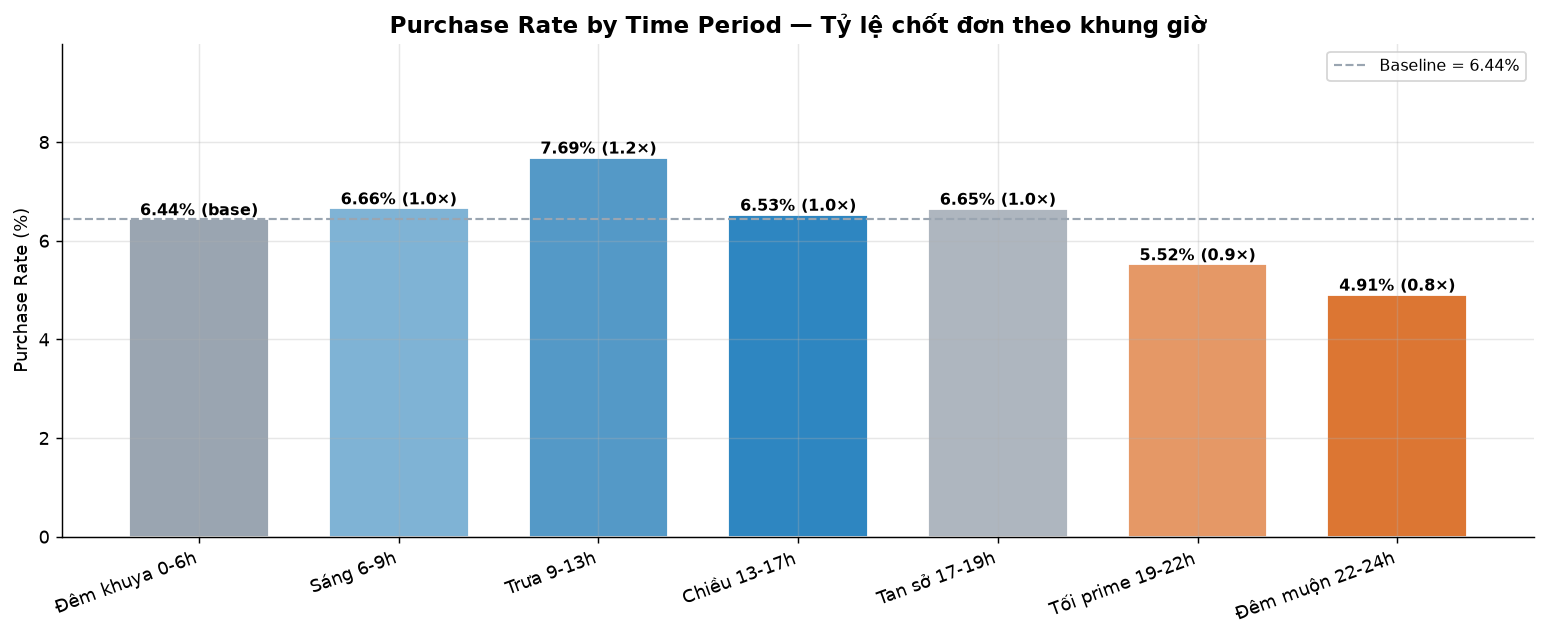

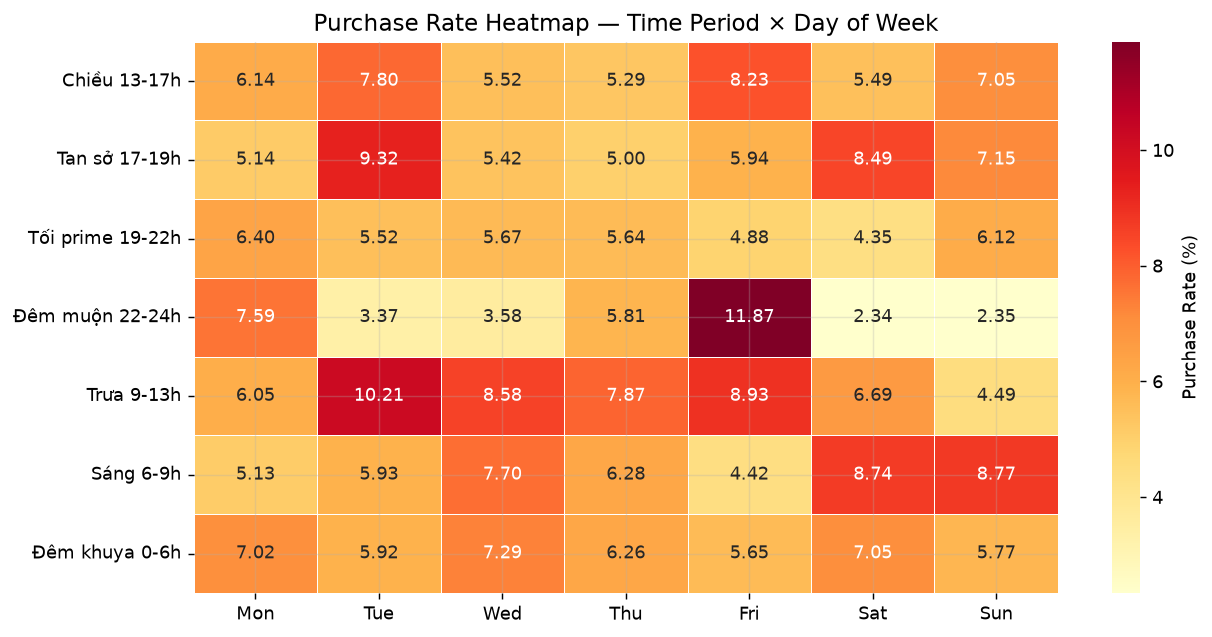

In [19]:
# ── Bar chart: purchase rate per time period ──
period_stats = df.groupby("time_period")["is_purchase"].mean().reindex(PERIOD_ORDER) * 100
base_rate    = float(period_stats.get("overnight_low", period_stats.min()))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    [PERIOD_LABEL[p] for p in PERIOD_ORDER],
    period_stats.values,
    color=[PERIOD_COLOR[p] for p in PERIOD_ORDER],
    edgecolor="white", width=0.7
)
for b_, v in zip(bars, period_stats.values):
    mult = f" ({v/base_rate:.1f}×)" if abs(v - base_rate) > 0.01 else " (base)"
    ax.text(b_.get_x() + b_.get_width()/2, v + 0.002,
            f"{v:.2f}%{mult}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(base_rate, color="#9aa5b1", ls="--", lw=1.2, label=f"Baseline = {base_rate:.2f}%")
ax.set_title("Purchase Rate by Time Period — Tỷ lệ chốt đơn theo khung giờ",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Purchase Rate (%)"); ax.set_ylim(0, period_stats.max() * 1.3)
ax.legend(fontsize=9); plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(FIG_DIR / "fig_timeslot_purchase.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Heatmap: time_period × day_of_week ──
DOW_LABEL = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
heat = df.pivot_table(values="is_purchase", index="time_period",
                      columns="dayofweek", aggfunc="mean") * 100
heat.index = [PERIOD_LABEL.get(p, p) for p in heat.index]
heat.columns = [DOW_LABEL[c] for c in heat.columns]

plt.figure(figsize=(10, 5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.4, cbar_kws={"label": "Purchase Rate (%)"})
plt.title("Purchase Rate Heatmap — Time Period × Day of Week", fontsize=13)
plt.xlabel(""); plt.ylabel(""); plt.tight_layout()
plt.savefig(FIG_DIR / "fig_heatmap_period_dow.png", dpi=150, bbox_inches="tight")
plt.show()


## §6 · Purchase Rate by Day-of-Month (Salary Periods)
Tác động của chu kỳ lương đến hành vi chốt đơn.

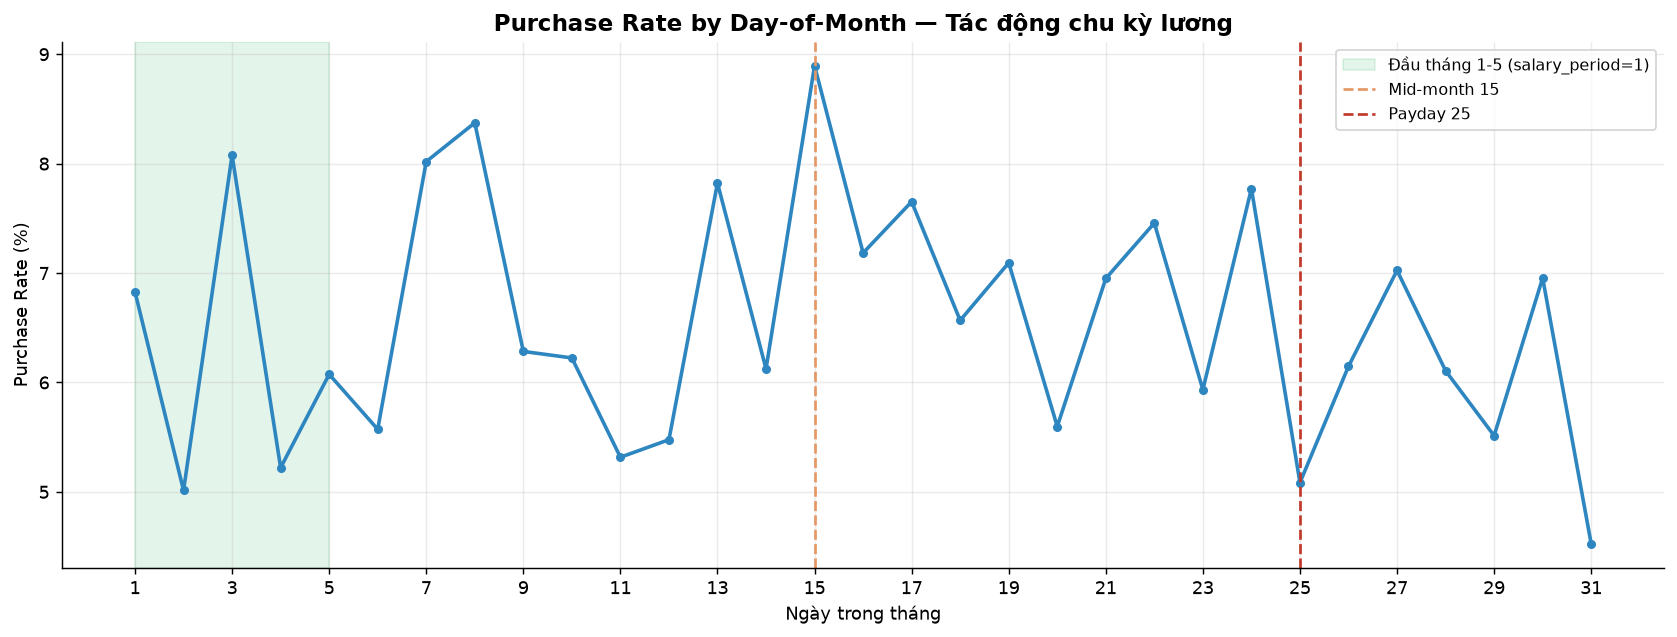

Tỷ lệ mua theo salary_period:
salary_period
Non-salary       0.0661
Salary period    0.0654
Name: is_purchase, dtype: float64


In [20]:
dom_pur = (df.groupby("dom")["is_purchase"].mean() * 100).reindex(range(1, 32))

plt.figure(figsize=(13, 5))
plt.plot(dom_pur.index, dom_pur.values, marker="o", color="#2e86c1", linewidth=2, markersize=4)
plt.axvspan(1, 5, color="#27ae60", alpha=.13, label="Đầu tháng 1-5 (salary_period=1)")
plt.axvline(15, color="#e59866", ls="--", lw=1.5, label="Mid-month 15")
plt.axvline(25, color="#c0392b", ls="--", lw=1.5, label="Payday 25")
plt.title("Purchase Rate by Day-of-Month — Tác động chu kỳ lương",
          fontsize=13, fontweight="bold")
plt.xlabel("Ngày trong tháng"); plt.ylabel("Purchase Rate (%)")
plt.xticks(range(1, 32, 2)); plt.legend(fontsize=9); plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_dom_purchase.png", dpi=150, bbox_inches="tight")
plt.show()
print("Tỷ lệ mua theo salary_period:")
print(df.groupby("salary_period")["is_purchase"].mean().rename({0:"Non-salary", 1:"Salary period"}).round(4))


## §7 · Correlation Heatmap: Behavior × Promotion Factors
Tương quan (Pearson) giữa hành vi khách hàng và các yếu tố khuyến mãi/thời gian.

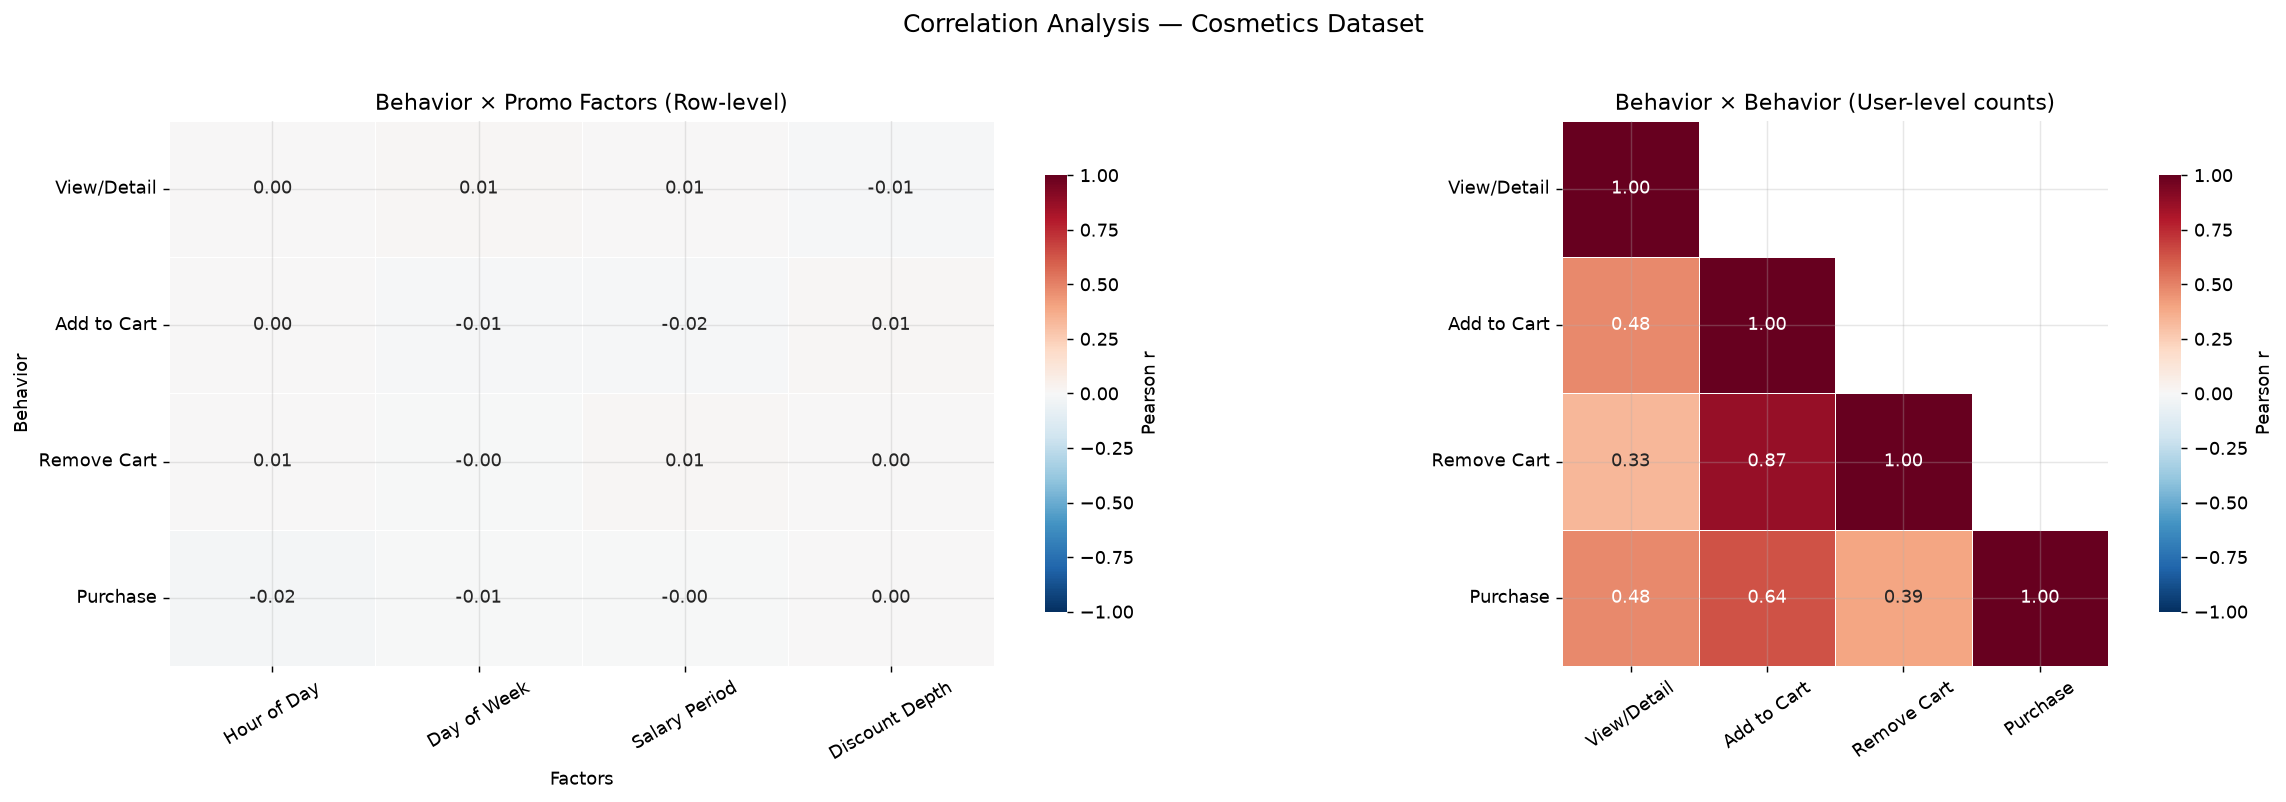


Correlation của is_purchase (user-level, sorted):
Add to Cart    0.635
View/Detail    0.484
Remove Cart    0.394
Name: Purchase, dtype: float64


In [21]:
beh_cols = [f"is_{b}" for b in BEHAV_ORDER]
ctx_cols = ["hour", "dayofweek", "salary_period", "discount_depth"]

beh_labels = {f"is_{b}": BEHAV_LABEL[b] for b in BEHAV_ORDER}
ctx_labels  = {"hour": "Hour of Day", "dayofweek": "Day of Week",
               "salary_period": "Salary Period", "discount_depth": "Discount Depth"}

# ── Row-level correlation ──
corr_row = df[beh_cols + ctx_cols].corr(method="pearson").loc[beh_cols, ctx_cols]
corr_row = corr_row.rename(index=beh_labels, columns=ctx_labels)

# ── User-level correlation ──
per_user = df.groupby("user_id")[beh_cols].sum()
corr_usr = per_user.corr(method="pearson").rename(index=beh_labels, columns=beh_labels)
mask_usr = np.triu(np.ones_like(corr_usr, dtype=bool), k=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(corr_row, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.4, ax=ax1,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax1.set_title("Behavior × Promo Factors (Row-level)", fontsize=12)
ax1.set_xlabel("Factors"); ax1.set_ylabel("Behavior")
ax1.tick_params(axis="x", rotation=30); ax1.tick_params(axis="y", rotation=0)

sns.heatmap(corr_usr, mask=mask_usr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.4, square=True, ax=ax2,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax2.set_title("Behavior × Behavior (User-level counts)", fontsize=12)
ax2.tick_params(axis="x", rotation=35); ax2.tick_params(axis="y", rotation=0)

plt.suptitle("Correlation Analysis — Cosmetics Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nCorrelation của is_purchase (user-level, sorted):")
print(corr_usr.loc["Purchase"].drop("Purchase").sort_values(ascending=False).round(3))


## §8 · Purchase Journey — Parallel Coordinates
Hành trình từ lần chạm đầu đến khi chốt đơn: số view, add-to-cart, remove, thời gian chờ, discount.

Purchase journeys found: 13,313
          n_view     n_cart   n_remove  wait_days   discount
count  13313.000  13313.000  13313.000  13313.000  13313.000
mean       0.738      1.445      0.274      5.341      0.012
std        1.389      1.968      0.849     15.935      0.047
min        0.000      0.000      0.000      0.000      0.000
25%        0.000      1.000      0.000      0.013      0.000
50%        0.000      1.000      0.000      0.060      0.000
75%        1.000      1.000      0.000      1.544      0.000
max       39.000    125.000     17.000    144.195      0.500


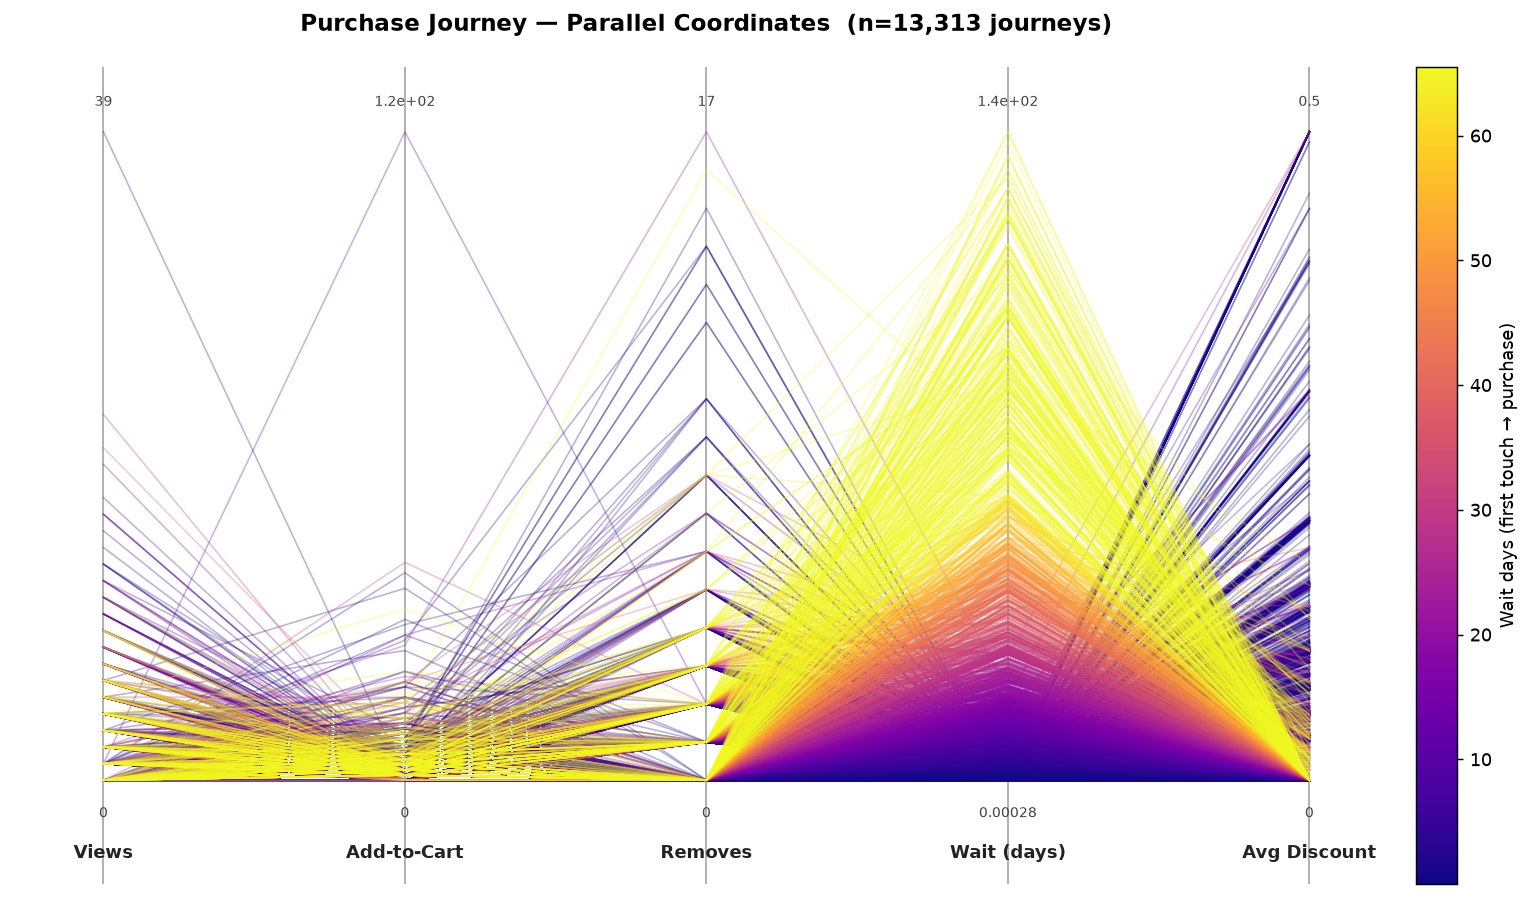

In [22]:
purchase_ev = df[df["is_purchase"] == 1][["user_id","product_id","ts"]].rename(columns={"ts":"pur_ts"})
other_ev    = df[df["is_purchase"] == 0][["user_id","product_id","ts","event_type_behav","discount_depth"]]

touch = other_ev.merge(purchase_ev, on=["user_id","product_id"], how="inner")
touch = touch[touch["ts"] <= touch["pur_ts"]]

records = []
for (uid, pid, pur_ts), g in touch.groupby(["user_id","product_id","pur_ts"]):
    records.append({
        "n_view":    int((g["event_type_behav"] == "detail_click").sum()),
        "n_cart":    int((g["event_type_behav"] == "add_to_cart").sum()),
        "n_remove":  int((g["event_type_behav"] == "remove_cart").sum()),
        "wait_days": (pur_ts - g["ts"].min()).total_seconds() / 86400,
        "discount":  float(g["discount_depth"].mean()),
    })

J = pd.DataFrame.from_records(records)
print(f"Purchase journeys found: {len(J):,}")
print(J.describe().round(3))

axes_cols = ["n_view","n_cart","n_remove","wait_days","discount"]
axes_vn   = ["Views","Add-to-Cart","Removes","Wait (days)","Avg Discount"]

Jn   = J[axes_cols].astype(float)
mins_, maxs_ = Jn.min(), Jn.max()
span_ = (maxs_ - mins_).replace(0, 1)
norm_ = (Jn - mins_) / span_

cvals = J["wait_days"].values
cmap  = plt.cm.plasma
vmax_ = np.percentile(cvals, 98); vmax_ = max(vmax_, cvals.min() + 0.01)
cnorm = Normalize(vmin=cvals.min(), vmax=vmax_)

x = np.arange(len(axes_cols))
fig, ax = plt.subplots(figsize=(13, 7))
for i in np.argsort(cvals):
    ax.plot(x, norm_.iloc[i].values, color=cmap(cnorm(cvals[i])), alpha=0.30, linewidth=0.9)
for xi, (col, vn) in enumerate(zip(axes_cols, axes_vn)):
    ax.axvline(xi, color="#aaa", lw=1, zorder=1)
    ax.text(xi, 1.04, f"{maxs_[col]:.2g}", ha="center", fontsize=8, color="#444")
    ax.text(xi, -0.04, f"{mins_[col]:.2g}", ha="center", fontsize=8, va="top", color="#444")
    ax.text(xi, -0.12, vn, ha="center", fontsize=10, fontweight="bold", color="#222")

ax.set_xticks([]); ax.set_yticks([]); ax.set_ylim(-0.16, 1.10); ax.set_xlim(-0.3, len(axes_cols)-0.7)
ax.set_title(f"Purchase Journey — Parallel Coordinates  (n={len(J):,} journeys)",
             fontsize=13, fontweight="bold", pad=20)
for s in ["top","right","left","bottom"]: ax.spines[s].set_visible(False)

sm = ScalarMappable(cmap=cmap, norm=cnorm); sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.01).set_label("Wait days (first touch → purchase)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_journey_parallel.png", dpi=150, bbox_inches="tight")
plt.show()


## §9 · Add-to-Cart → Purchase Gap Distribution
Phân phối thời gian từ lúc thêm giỏ đến khi chốt đơn (tính bằng phút).

Add→Purchase pairs: 12,914
  ≤ 30 min                 :  41.7%  (5385 pairs)
  ≤ 1 h                    :  52.8%  (6815 pairs)
  ≤ 2 h (2h window)        :  61.1%  (7893 pairs)
  ≤ 1 day                  :  79.5%  (10261 pairs)
  ≤ 7 days                 :  91.5%  (11815 pairs)
  Median: 50.4 min | Mean: 3106.2 min


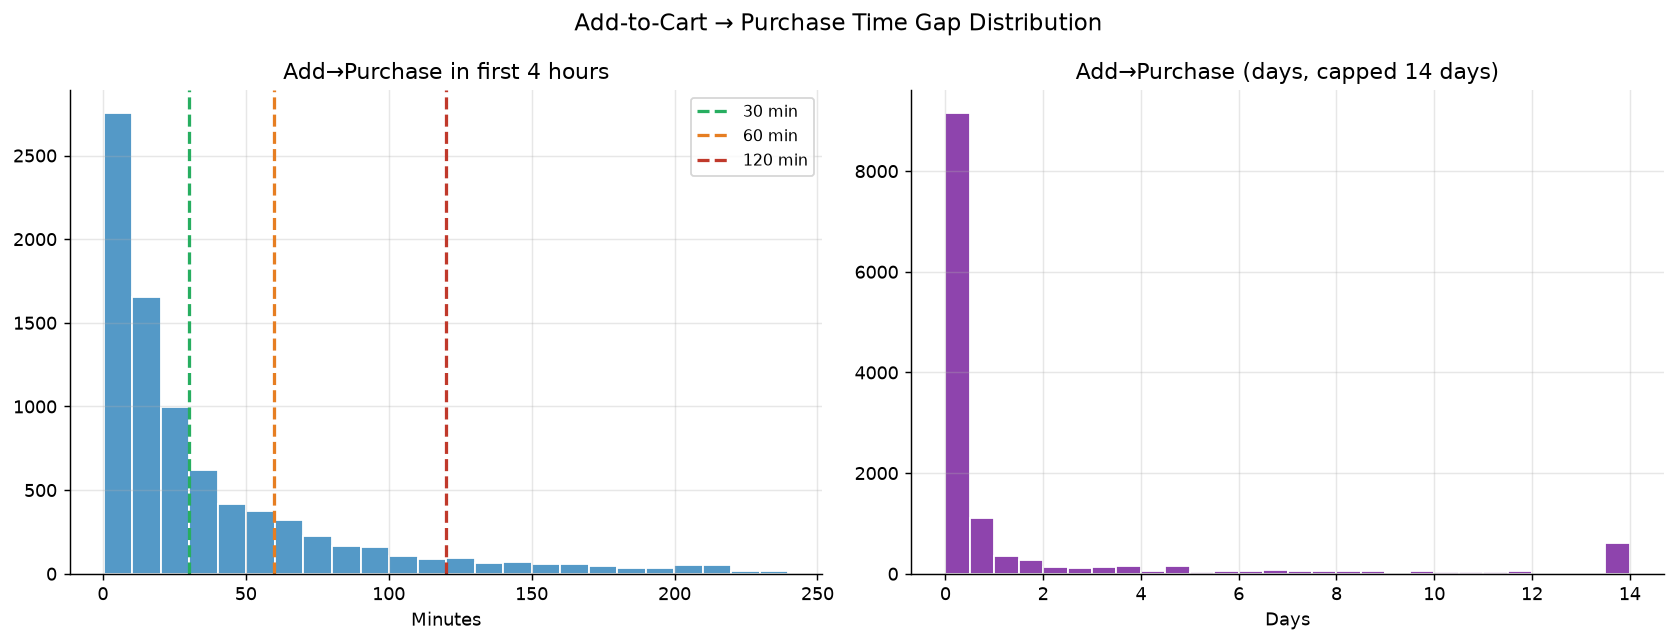

In [23]:
d_gap = df.copy().sort_values(["user_id","product_id","ts"])
gaps  = []
for (uid, pid), g in d_gap.groupby(["user_id","product_id"]):
    adds = g.loc[g["event_type_behav"] == "add_to_cart", "ts"]
    buys = g.loc[g["event_type_behav"] == "purchase",    "ts"]
    for pt in buys:
        prev = adds[adds <= pt]
        if len(prev):
            gaps.append((pt - prev.max()).total_seconds() / 60)
gaps = np.array(gaps)

print(f"Add→Purchase pairs: {len(gaps):,}")
for label, cut in [("≤ 30 min", 30), ("≤ 1 h", 60), ("≤ 2 h (2h window)", 120),
                   ("≤ 1 day", 1440), ("≤ 7 days", 10080)]:
    print(f"  {label:25s}: {(gaps<=cut).mean()*100:5.1f}%  ({int((gaps<=cut).sum())} pairs)")
print(f"  Median: {np.median(gaps):.1f} min | Mean: {gaps.mean():.1f} min")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(gaps[gaps <= 240], bins=24, color="#5499c7", edgecolor="white")
for cut, color, lbl in [(30,"#27ae60","30 min"),(60,"#e67e22","60 min"),(120,"#c0392b","120 min")]:
    ax1.axvline(cut, ls="--", color=color, lw=1.8, label=lbl)
ax1.set_title("Add→Purchase in first 4 hours"); ax1.set_xlabel("Minutes"); ax1.legend(fontsize=9)

ax2.hist(np.clip(gaps/1440, 0, 14), bins=28, color="#8e44ad", edgecolor="white")
ax2.set_title("Add→Purchase (days, capped 14 days)"); ax2.set_xlabel("Days")

plt.suptitle("Add-to-Cart → Purchase Time Gap Distribution", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_add_to_purchase_gap.png", dpi=150, bbox_inches="tight")
plt.show()


## §10 · Chốt nhanh vs Chốt muộn — First Touch → Purchase
Phân tích tỷ lệ 'chốt nhanh' (< 3 ngày) vs 'chốt muộn' (≥ 3 ngày) theo khung giờ.

Orders: 14,194 | delayed (≥3d): 2768 (20%)


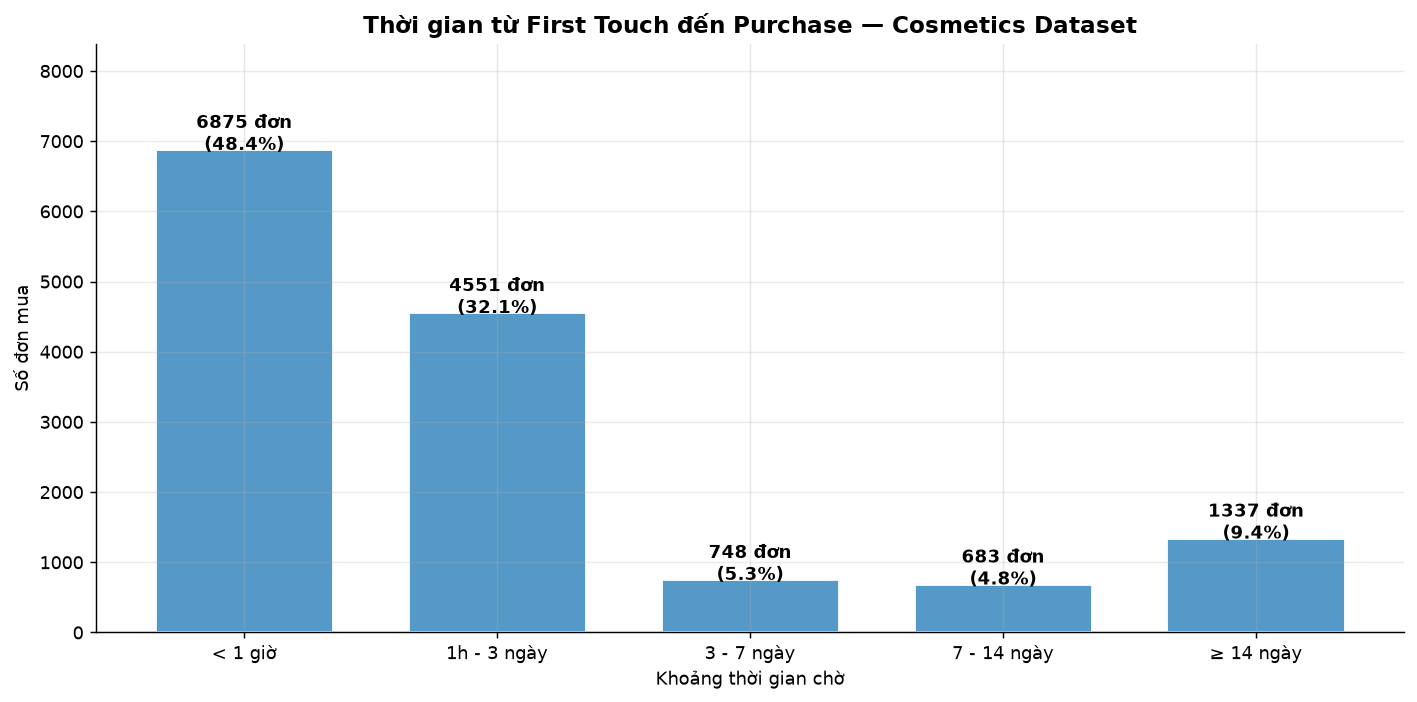

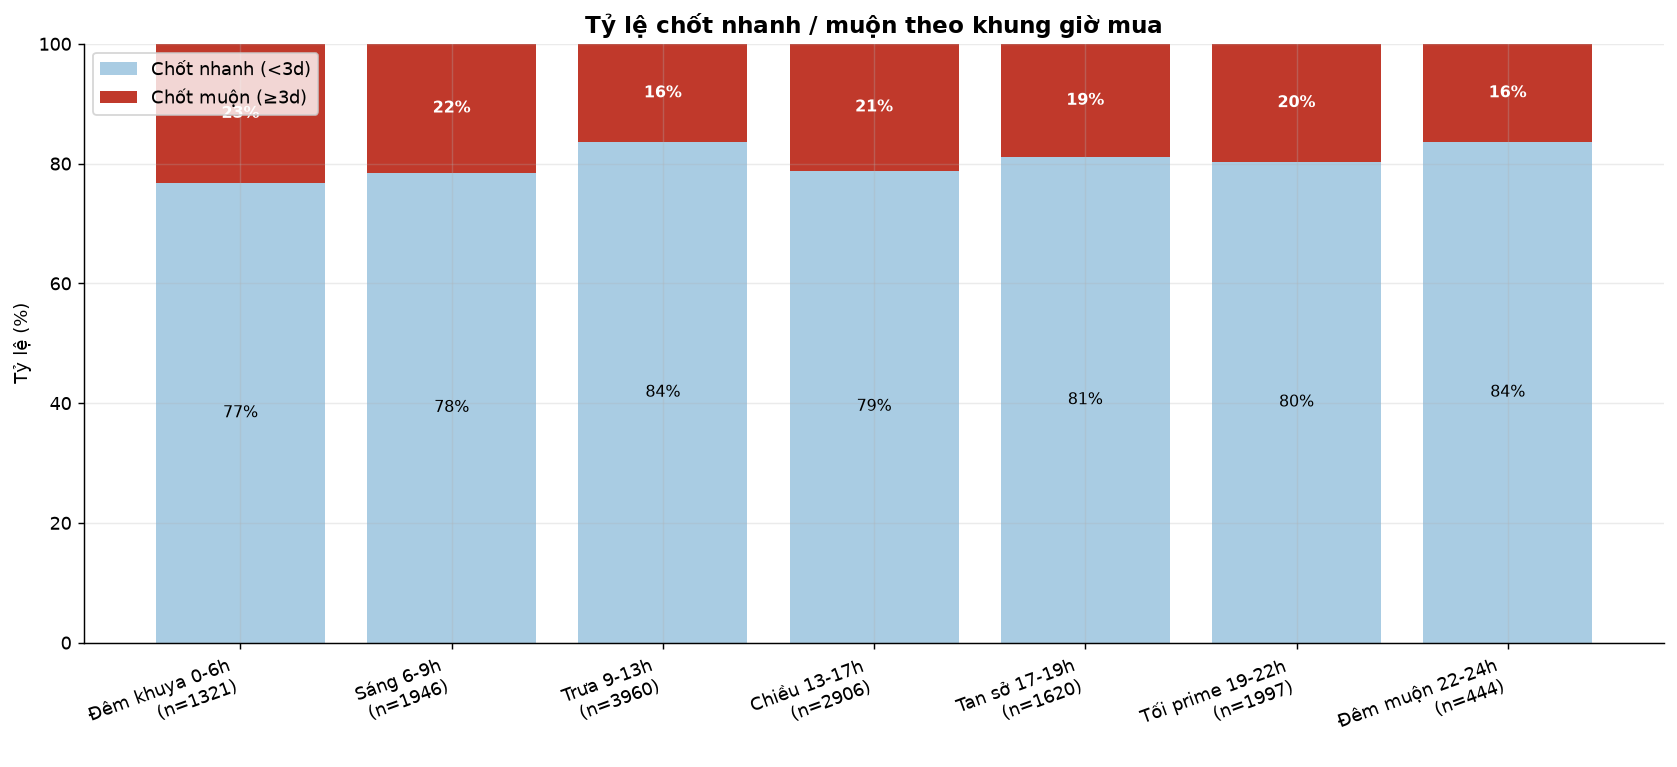

In [24]:
# Build first-touch → purchase dataframe
pur_df   = df[df["is_purchase"]==1][["user_id","product_id","ts","time_period"]].rename(columns={"ts":"pur_ts"})
touch_df = df[df["is_purchase"]==0][["user_id","product_id","ts"]].merge(
    pur_df[["user_id","product_id","pur_ts"]], on=["user_id","product_id"], how="inner")
touch_df = touch_df[touch_df["ts"] <= touch_df["pur_ts"]]
first_t  = (touch_df.groupby(["user_id","product_id","pur_ts"], as_index=False)["ts"]
                    .min().rename(columns={"ts":"first_ts"}))
p2 = pur_df.merge(first_t, on=["user_id","product_id","pur_ts"], how="left")
p2["first_ts"] = p2["first_ts"].fillna(p2["pur_ts"])
p2["wait_h"]   = (p2["pur_ts"] - p2["first_ts"]).dt.total_seconds() / 3600
p2["delayed"]  = p2["wait_h"] >= 72
print(f"Orders: {len(p2):,} | delayed (≥3d): {int(p2['delayed'].sum())} ({p2['delayed'].mean():.0%})")

# ── 5-group bar chart ──
wait_labels = ["< 1 giờ", "1h - 3 ngày", "3 - 7 ngày", "7 - 14 ngày", "≥ 14 ngày"]
p2["wait_group"] = pd.cut(p2["wait_h"], bins=[0,1,72,168,336,np.inf],
                          labels=wait_labels, right=False, include_lowest=True)
wc = p2["wait_group"].value_counts().reindex(wait_labels, fill_value=0)
wp = wc / len(p2) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(wc.index, wc.values, color="#5499c7", edgecolor="white", width=0.7)
for b, ct, pct in zip(bars, wc.values, wp.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f"{ct} đơn\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Thời gian từ First Touch đến Purchase — Cosmetics Dataset",
             fontsize=13, fontweight="bold"); ax.set_xlabel("Khoảng thời gian chờ")
ax.set_ylabel("Số đơn mua"); ax.set_ylim(0, wc.max()*1.22)
ax.grid(axis="y", alpha=0.25); plt.tight_layout()
plt.savefig(FIG_DIR / "fig_wait_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Stacked bar: fast vs slow by time_period ──
tp_wait = (pd.crosstab(p2["time_period"], p2["delayed"])
             .reindex(PERIOD_ORDER, fill_value=0).reindex(columns=[False, True], fill_value=0))
tp_wait.columns = ["Chốt nhanh (<3d)", "Chốt muộn (≥3d)"]
tp_total = tp_wait.sum(axis=1)
tp_pct   = tp_wait.div(tp_total.replace(0,np.nan), axis=0).mul(100).fillna(0)
tp_labels = [f"{PERIOD_LABEL[p]}\n(n={int(tp_total.get(p,0))})" for p in PERIOD_ORDER]

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(tp_labels, tp_pct["Chốt nhanh (<3d)"], color="#a9cce3", label="Chốt nhanh (<3d)")
ax.bar(tp_labels, tp_pct["Chốt muộn (≥3d)"], bottom=tp_pct["Chốt nhanh (<3d)"],
       color="#c0392b", label="Chốt muộn (≥3d)")
for i, p in enumerate(PERIOD_ORDER):
    q = tp_pct.loc[p,"Chốt nhanh (<3d)"]; dl = tp_pct.loc[p,"Chốt muộn (≥3d)"]
    if q  >= 8: ax.text(i, q/2, f"{q:.0f}%", ha="center", va="center", fontsize=9)
    if dl >= 8: ax.text(i, q+dl/2, f"{dl:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax.set_title("Tỷ lệ chốt nhanh / muộn theo khung giờ mua",
             fontsize=13, fontweight="bold"); ax.set_ylim(0, 100)
ax.set_ylabel("Tỷ lệ (%)"); ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.25); plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(FIG_DIR / "fig_wait_by_period.png", dpi=150, bbox_inches="tight")
plt.show()


## §11 · Session Length Distribution
Phân bố số action / session (ngưỡng ngưng 30 phút). Bao nhiêu action tối đa?

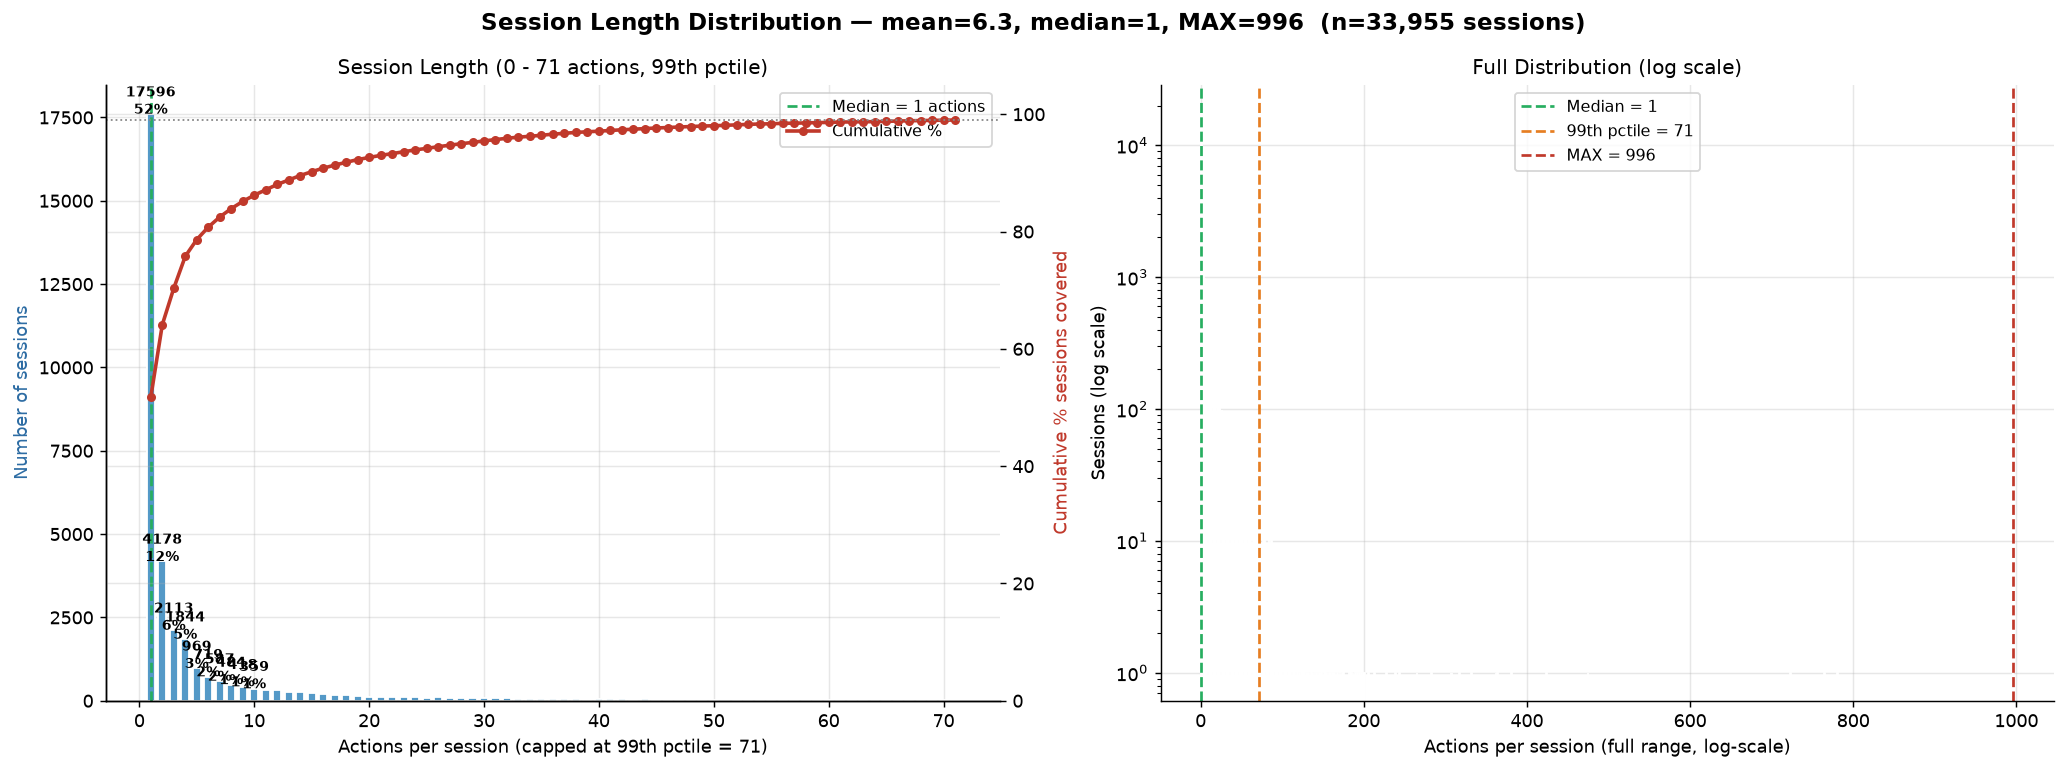

Sessions: 33,955 | Mean=6.34 | Median=1 | MAX=996
99th pctile: 71 actions
  ≤  1 action:  51.8% of sessions
  ≤  2 action:  64.1% of sessions
  ≤  3 action:  70.3% of sessions
  ≤  4 action:  75.8% of sessions
  ≤  5 action:  78.6% of sessions
  ≤  6 action:  80.8% of sessions
  ≤ 10 action:  86.2% of sessions
  ≤ 20 action:  92.6% of sessions


In [25]:
sess_len = df.groupby("session_id").size().values
mean_,  med_,  mx_ = sess_len.mean(), np.median(sess_len), sess_len.max()

# Cap display at 99th percentile to prevent the long tail from squishing the distribution
cap_val  = int(np.percentile(sess_len, 99))
u_all, c_all = np.unique(sess_len, return_counts=True)
cum_all  = np.cumsum(c_all) / len(sess_len) * 100

# For bar plot: cap at 99th percentile
mask = u_all <= cap_val
u, c_ = u_all[mask], c_all[mask]
cum_  = np.cumsum(c_) / len(sess_len) * 100

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Capped bar chart (up to 99th pctile)
bars = ax1.bar(u, c_, color="#5499c7", edgecolor="white", width=0.7, zorder=2)
top_u = u[c_ > len(sess_len) * 0.01]
for x_, v in zip(u, c_):
    if x_ in top_u:
        ax1.text(x_, v + 15, f"{v}\n{v/len(sess_len)*100:.0f}%",
                 ha="center", fontsize=8, fontweight="bold")
ax2 = ax1.twinx()
ax2.plot(u, cum_, color="#c0392b", marker="o", lw=2, markersize=4, label="Cumulative %")
ax2.set_ylabel("Cumulative % sessions covered", color="#c0392b"); ax2.set_ylim(0, 105)
ax2.axhline(99, ls=":", color="#888", lw=1)
ax1.axvline(med_, color="#27ae60", ls="--", lw=1.5, label=f"Median = {med_:.0f} actions")
ax1.set_xlabel(f"Actions per session (capped at 99th pctile = {cap_val})", fontsize=10)
ax1.set_ylabel("Number of sessions", color="#2e6da4")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper right", fontsize=9)
ax1.set_title(f"Session Length (0 - {cap_val} actions, 99th pctile)", fontsize=11)

# Right: Log-scale full distribution  
ax3.bar(u_all, c_all, color="#8e44ad", edgecolor="white", width=0.7, log=True, zorder=2)
ax3.axvline(med_,    color="#27ae60", ls="--", lw=1.5, label=f"Median = {med_:.0f}")
ax3.axvline(cap_val, color="#e67e22", ls="--", lw=1.5, label=f"99th pctile = {cap_val}")
ax3.axvline(mx_,     color="#c0392b", ls="--", lw=1.5, label=f"MAX = {int(mx_)}")
ax3.set_xlabel("Actions per session (full range, log-scale)"); ax3.set_ylabel("Sessions (log scale)")
ax3.legend(fontsize=9); ax3.set_title("Full Distribution (log scale)", fontsize=11)

plt.suptitle(
    f"Session Length Distribution — mean={mean_:.1f}, median={med_:.0f}, MAX={int(mx_)}  (n={len(sess_len):,} sessions)",
    fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_session_length.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Sessions: {len(sess_len):,} | Mean={mean_:.2f} | Median={med_:.0f} | MAX={int(mx_)}")
print(f"99th pctile: {cap_val} actions")
for L in [1, 2, 3, 4, 5, 6, 10, 20]:
    print(f"  ≤ {L:2d} action: {(sess_len<=L).mean()*100:5.1f}% of sessions")


## §12 · Export Summary Tables

In [26]:
# Brand summary
brand_summary = (
    df[df["brand_group"].isin(top10_brands)]
      .groupby("brand_group")
      .agg(
          n_events       = ("event_type_behav", "count"),
          n_users        = ("user_id",          "nunique"),
          n_products     = ("product_id",        "nunique"),
          view_rate      = ("is_detail_click",  "mean"),
          cart_rate      = ("is_add_to_cart",   "mean"),
          purchase_rate  = ("is_purchase",      "mean"),
          avg_price      = ("price",             "mean"),
          avg_discount   = ("discount_depth",   "mean"),
      )
      .round(4)
      .sort_values("purchase_rate", ascending=False)
)
brand_summary.to_csv(OUT_DIR / "eda_brand_summary.csv")
print("Brand Summary:")
print(brand_summary.to_string())

# Time period summary
period_summary = (
    df.groupby("time_period")
      .agg(
          n_events      = ("event_type_behav", "count"),
          view_rate     = ("is_detail_click",  "mean"),
          cart_rate     = ("is_add_to_cart",   "mean"),
          purchase_rate = ("is_purchase",      "mean"),
          avg_discount  = ("discount_depth",   "mean"),
      )
      .reindex(PERIOD_ORDER)
      .round(4)
)
period_summary.index = [PERIOD_LABEL[p] for p in period_summary.index]
period_summary.to_csv(OUT_DIR / "eda_timeperiod_summary.csv")
print("\nTime Period Summary:")
print(period_summary.to_string())

print(f"\n✓ Saved: {OUT_DIR}/eda_brand_summary.csv")
print(f"✓ Saved: {OUT_DIR}/eda_timeperiod_summary.csv")
print(f"\nAll figures saved to: {FIG_DIR}")
import os
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {f}")


Brand Summary:
             n_events  n_users  n_products  view_rate  cart_rate  purchase_rate  avg_price  avg_discount
brand_group                                                                                             
bpw.style        4040      533         237     0.3844     0.3017         0.0988     1.1796        0.0109
runail          16196     2262        1097     0.3951     0.3100         0.0792     5.9146        0.0119
irisk           11023     1844         988     0.4042     0.3111         0.0782     5.8570        0.0081
unknown         89904     8148       11393     0.4586     0.2778         0.0673     7.2104        0.0132
masura           8712     1013         882     0.3887     0.2856         0.0605     3.3878        0.0060
estel            3150     1031         424     0.5863     0.2333         0.0581     7.3333        0.0035
kapous           3142      986         215     0.5961     0.2272         0.0573     3.9611        0.0043
ingarden         5004      721         4